# Predictive Modeling — Credit Delinquency Risk

This notebook builds and evaluates classification models to predict serious credit delinquency (`SeriousDlqin2yrs`) using the clustered and cleaned dataset from earlier notebooks. Two models are trained and compared: logistic regression as an interpretable baseline, and a decision tree for its ability to capture non-linear relationships.

Beyond prediction accuracy, the goal is to understand **which features drive delinquency risk** — and to generate risk scores that feed into the product framing in `04_product_framing.ipynb`.

**Key questions explored:**
- Which features are most predictive of serious delinquency?
- How do logistic regression and decision tree compare in performance?
- How do we handle class imbalance (6.7% positive rate) without sacrificing recall?

**Approach:**
- Train/test split and class imbalance handling via `class_weight='balanced'`
- Logistic regression baseline
- Decision tree classifier
- Evaluation via precision, recall, AUC-ROC — not raw accuracy
- Feature importance analysis

**Input:** `data/clustered.csv` from `02_segmentation.ipynb`  
**Output:** Risk scores and model insights carried into `04_product_framing.ipynb`

## 1. Load clustered.csv + Define targets

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, roc_auc_score,
                             roc_curve, ConfusionMatrixDisplay)
import statsmodels.api as sm

In [2]:
df = pd.read_csv('data/clustered.csv')

print(df.shape)
print(df.columns.tolist())

(150000, 22)
['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents', 'MonthlyIncome_log', 'DebtRatio_log', 'EverLate30', 'EverLate60', 'EverLate90', 'DebtRatio_high', 'cluster', 'cluster_name', 'pca1', 'pca2', 'product_recommendation']


In [3]:
features = [
    'RevolvingUtilizationOfUnsecuredLines',
    'MonthlyIncome_log',
    'EverLate30',
    'EverLate60',
    'EverLate90',
    'DebtRatio_high',
    'age',
    'NumberOfOpenCreditLinesAndLoans',
    'NumberRealEstateLoansOrLines',
    'NumberOfDependents'
]

In [4]:
X = df[features]
y = df['SeriousDlqin2yrs']

print(y.value_counts(normalize=True).round(3))

SeriousDlqin2yrs
0.0    0.933
1.0    0.067
Name: proportion, dtype: float64


## 2. Train/test split

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
print(f"Train: {X_train.shape[0]} rows")
print(f"Test: {X_test.shape[0]} rows")
print(f"Train positive rate: {y_train.mean().round(3)}")
print(f"Test positive rate: {y_test.mean().round(3)}")

Train: 120000 rows
Test: 30000 rows
Train positive rate: 0.067
Test positive rate: 0.067


## 3. Logistic Regression

In [7]:
lr = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [8]:
print("Logistic Regression")
print(classification_report(y_test, y_pred_lr))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_lr):.3f}")

Logistic Regression
              precision    recall  f1-score   support

         0.0       0.98      0.81      0.89     27995
         1.0       0.22      0.75      0.35      2005

    accuracy                           0.81     30000
   macro avg       0.60      0.78      0.62     30000
weighted avg       0.93      0.81      0.85     30000

AUC-ROC: 0.866


In [10]:
X_train_sm = sm.add_constant(X_train)
logit_model = sm.Logit(y_train, X_train_sm)
result = logit_model.fit()
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.181724
         Iterations 8
                           Logit Regression Results                           
Dep. Variable:       SeriousDlqin2yrs   No. Observations:               120000
Model:                          Logit   Df Residuals:                   119989
Method:                           MLE   Df Model:                           10
Date:                Sun, 17 May 2026   Pseudo R-squ.:                  0.2595
Time:                        14:39:07   Log-Likelihood:                -21807.
converged:                       True   LL-Null:                       -29447.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
const                                   -5.7254      0.1

## Logistic Regression Results

### Model Fit
- **Pseudo R²: 0.26** — solid for credit risk data; these models rarely exceed 0.30 in real-world financial datasets due to inherent noise in borrower behavior
- **LLR p-value: 0.000** — model is significantly better than a null (intercept-only) model across all 10 features

### Coefficients & Statistical Significance

All features are statistically significant at p < 0.05 except `NumberOfDependents` (p = 0.242), which will be excluded from the decision tree feature set.

Coefficients represent the change in log-odds of serious delinquency for a one-unit increase in each feature, holding all others constant. For binary features (`EverLate30`, `EverLate60`, `EverLate90`, `DebtRatio_high`), the reference category is 0 (never occurred).

| Feature | Coefficient | Interpretation |
|---|---|---|
| `RevolvingUtilizationOfUnsecuredLines` | +1.70 | Strongest predictor — higher credit utilization significantly increases delinquency risk |
| `EverLate90` | +1.53 | Prior severe delinquency nearly as predictive as utilization |
| `EverLate60` | +1.02 | Escalating delinquency history meaningfully increases risk |
| `EverLate30` | +0.93 | Even early missed payments are a significant risk signal |
| `DebtRatio_high` | +0.65 | Debt obligations exceeding income increases delinquency risk |
| `MonthlyIncome_log` | +0.27 | Positive coefficient likely reflects higher-income borrowers carrying greater credit exposure |
| `NumberRealEstateLoansOrLines` | +0.05 | Small but significant positive effect |
| `NumberOfOpenCreditLinesAndLoans` | +0.02 | Small but significant positive effect |
| `age` | -0.02 | Older borrowers slightly less likely to default — consistent with EDA findings |
| `NumberOfDependents` | +0.01 | **Not significant (p = 0.242)** — excluded from further modeling |

### Classification Performance
- **AUC-ROC: 0.866** — strong discriminatory power
- **Recall on delinquent class: 0.75** — model correctly identifies 75% of borrowers who will default, prioritizing detection over precision
- **Precision on delinquent class: 0.22** — expected given class imbalance and `class_weight='balanced'`; the model trades precision for recall, appropriate for a credit risk context where missing a defaulter is more costly than a false alarm

## 4. Descision Tree

In [11]:
dt = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=42,
    max_depth=5,
    min_samples_leaf=50
)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

In [12]:
print("Decision Tree")
print(classification_report(y_test, y_pred_dt))
print(f"AUC-ROC: {roc_auc_score(y_test, y_prob_dt):.3f}")

Decision Tree
              precision    recall  f1-score   support

         0.0       0.99      0.69      0.81     27995
         1.0       0.17      0.86      0.28      2005

    accuracy                           0.70     30000
   macro avg       0.58      0.78      0.54     30000
weighted avg       0.93      0.70      0.77     30000

AUC-ROC: 0.848


## 5. Model comparison

In [13]:
comparison = pd.DataFrame({
    'Metric': ['Precision (class 1)', 'Recall (class 1)', 'F1 (class 1)', 'AUC-ROC', 'Accuracy'],
    'Logistic Regression': [0.22, 0.75, 0.35, 0.866, 0.81],
    'Decision Tree': [0.17, 0.86, 0.28, 0.848, 0.70]
})

print(comparison.to_string(index=False))

             Metric  Logistic Regression  Decision Tree
Precision (class 1)                0.220          0.170
   Recall (class 1)                0.750          0.860
       F1 (class 1)                0.350          0.280
            AUC-ROC                0.866          0.848
           Accuracy                0.810          0.700


**Logistic regression is the stronger model overall** — higher AUC-ROC (0.866 vs 0.848), higher precision, and higher accuracy. It correctly identifies 75% of borrowers who will default while generating fewer false alarms than the decision tree.

**The decision tree achieves higher recall (0.86 vs 0.75)** — it catches more actual defaulters, but at the cost of flagging more good borrowers as risky (lower precision of 0.17). Lower overall accuracy (0.70) reflects this tradeoff.

**In a credit risk context, logistic regression is preferred.** Missing a defaulter (low recall) is costly, but so is incorrectly denying credit to a creditworthy borrower. Logistic regression strikes a better balance between the two, and its higher AUC-ROC confirms stronger overall discriminatory power across all classification thresholds.

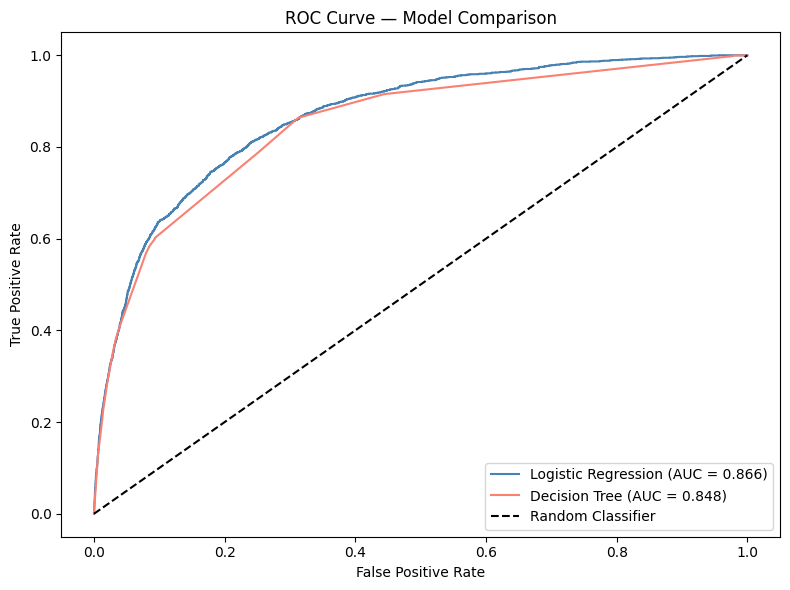

In [14]:
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8, 6))
plt.plot(fpr_lr, tpr_lr, color='steelblue', label=f'Logistic Regression (AUC = 0.866)')
plt.plot(fpr_dt, tpr_dt, color='salmon', label=f'Decision Tree (AUC = 0.848)')
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend()
plt.tight_layout()
plt.show()

## 6. Feature Importance

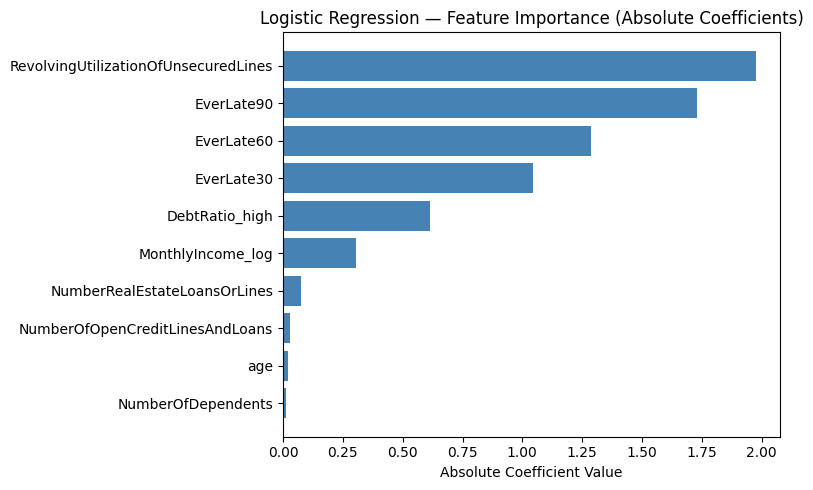

In [15]:
coef_df = pd.DataFrame({
    'feature': features,
    'importance': np.abs(lr.coef_[0])
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(coef_df['feature'], coef_df['importance'], color='steelblue', edgecolor='none')
plt.title('Logistic Regression — Feature Importance (Absolute Coefficients)')
plt.xlabel('Absolute Coefficient Value')
plt.tight_layout()
plt.show()

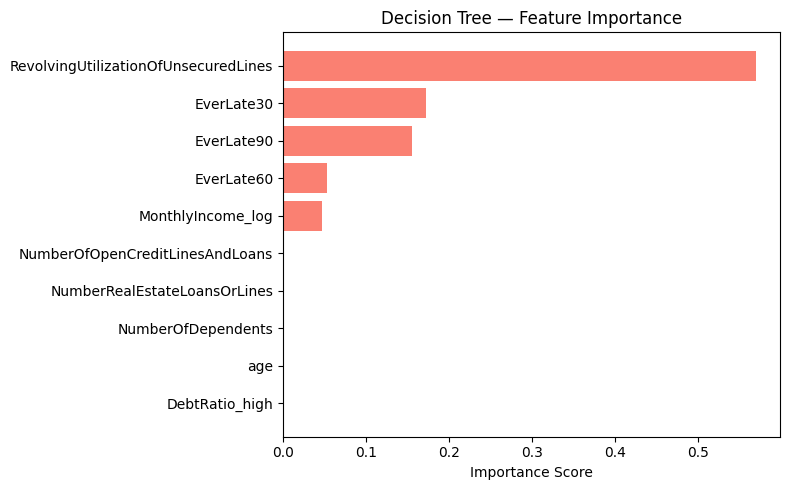

In [16]:
dt_imp = pd.DataFrame({
    'feature': features,
    'importance': dt.feature_importances_
}).sort_values('importance', ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(dt_imp['feature'], dt_imp['importance'], color='salmon', edgecolor='none')
plt.title('Decision Tree — Feature Importance')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

## Feature Importance

### Logistic Regression — Absolute Coefficients
| Rank | Feature | Importance |
|---|---|---|
| 1 | RevolvingUtilizationOfUnsecuredLines | 1.96 |
| 2 | EverLate90 | 1.70 |
| 3 | EverLate60 | 1.28 |
| 4 | EverLate30 | 1.05 |
| 5 | DebtRatio_high | 0.63 |
| 6 | MonthlyIncome_log | 0.29 |
| 7–10 | RealEstateLoans, OpenCreditLines, age, Dependents | <0.10 |

### Decision Tree — Feature Importance
| Rank | Feature | Importance |
|---|---|---|
| 1 | RevolvingUtilizationOfUnsecuredLines | 0.55 |
| 2 | EverLate30 | 0.17 |
| 3 | EverLate90 | 0.15 |
| 4 | EverLate60 | 0.05 |
| 5 | MonthlyIncome_log | 0.04 |
| 6–10 | Remaining features | ~0.00 |

### Key Takeaways
Both models converge on the same top features, providing strong cross-model validation:

- **RevolvingUtilizationOfUnsecuredLines** is the dominant predictor in both models — how much of available credit a borrower is using is the single strongest signal of delinquency risk
- **Delinquency history** (EverLate30/60/90) consistently ranks highly across both models — past behavior is a reliable predictor of future default
- **DebtRatio_high** contributes meaningfully in logistic regression but is near-zero in the decision tree — suggests its effect may be captured by other features in the tree structure
- **Demographic and credit footprint features** (age, dependents, open lines) contribute minimally — behavioral signals dominate over demographic ones

## 7. Save model outputs

In [17]:
df['risk_score_lr'] = lr.predict_proba(df[features])[:, 1]
df['risk_score_dt'] = dt.predict_proba(df[features])[:, 1]
df['predicted_delinquent_lr'] = lr.predict(df[features])
df['predicted_delinquent_dt'] = dt.predict(df[features])


In [18]:
df.head()

,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,...,DebtRatio_high,cluster,cluster_name,pca1,pca2,product_recommendation,risk_score_lr,risk_score_dt,predicted_delinquent_lr,predicted_delinquent_dt
0,1.0,0.766127,45.0,2.0,0.802982,9120.0,13.0,0.0,6.0,0.0,...,0,3,Early Risk,1.745616,-0.295054,PRIMARY TARGET — credit builder line + financi...,0.836885,0.778058,1.0,1.0
1,0.0,0.957151,40.0,0.0,0.121876,2600.0,4.0,0.0,0.0,0.0,...,0,0,Established & Stable,0.822982,-0.240536,Not a primary target — already credit healthy,0.504161,0.547649,1.0,1.0
2,0.0,0.658180,38.0,1.0,0.085113,3042.0,2.0,1.0,0.0,0.0,...,0,2,Seriously Delinquent,3.628291,0.820397,Debt counseling — not ready for credit building,0.904660,0.929610,1.0,1.0
3,0.0,0.233810,30.0,0.0,0.036050,3300.0,5.0,0.0,0.0,0.0,...,0,0,Established & Stable,0.109489,-0.577869,Not a primary target — already credit healthy,0.253926,0.300189,0.0,0.0
4,0.0,0.907239,49.0,1.0,0.024926,63588.0,7.0,0.0,1.0,0.0,...,0,3,Early Risk,2.035956,-0.793329,PRIMARY TARGET — credit builder line + financi...,0.870358,0.778058,1.0,1.0


In [19]:
print(df[['cluster_name', 'risk_score_lr', 'risk_score_dt']].groupby('cluster_name').mean().round(3))

                      risk_score_lr  risk_score_dt
cluster_name                                      
Debt Burdened                 0.197          0.200
Early Risk                    0.619          0.657
Established & Stable          0.269          0.266
Seriously Delinquent          0.868          0.875


In [20]:
df.to_csv('data/modeled.csv', index=False)